# Clasificacion

En el capitulo anterior pusimos total atencion en algunos de los algoritmos mas usados en **regresion**, ahora nos enfocaremos en los algoritmos mas usados cuando tenemos problemas de **clasificacion**. Y para esto, lo que haremos será usar uno de los Datasets que es como el "hello world" para todo Cientifico de Datos cuando se trata de clasificacion y es el **MNIST**

In [15]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml("mnist_784", version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

Guardamos las variables predictoras y el target

In [16]:
X, y = mnist.data, mnist.target

In [17]:
X

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
y

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: category
Categories (10, str): ['0', '1', '2', '3', ..., '6', '7', '8', '9']

El dataset consiste en 70.000 imagenes que tienen digitos, pero cada imagen , sería en este caso una fila, donde cada fila tiene 784 **features** ya que las imagenes son de **28x28** lo que hace que cada feature va a representar una intensidad de pixel de 0 (blanco) a 255 (negro)

Veamos una de las imagenes

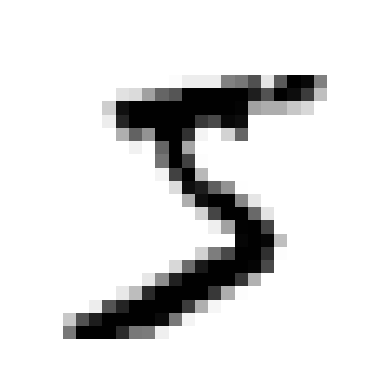

In [19]:
import matplotlib.pyplot as plt

some_digit = X.iloc[0].values
image = some_digit.reshape(28,28)

plt.imshow(image,cmap="binary")
plt.axis("off")
plt.show()

In [20]:
print(f"La etiqueta de esta imagen es: {y[0]}")

La etiqueta de esta imagen es: 5


In [21]:
import numpy as np
y = y.astype(np.uint8)

Vamos a crear un conjunto de Train y otro de test

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Por ahora vamos a enfocarnos en hacer un claificador **binario** como por ejemplo identificar si un numero es 5 o no es 5

In [23]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

Empecemos usando un clasificar SGD o de Grandiente Descendente Estocastico, el cual, trabaja muy rapido ya que usa cada sample por separado lo cual lo hace tambien un muy buen algoritmo para largos datasets y para **online learning**

In [24]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier()
sgd_clf.fit(X_train,y_train_5)

,"loss loss: {'hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive'}, default='hinge'The loss function to be used.- 'hinge' gives a linear SVM.- 'log_loss' gives logistic regression, a probabilistic classifier.- 'modified_huber' is another smooth loss that brings tolerance to outliers as well as probability estimates.- 'squared_hinge' is like hinge but is quadratically penalized.- 'perceptron' is the linear loss used by the perceptron algorithm.- The other losses, 'squared_error', 'huber', 'epsilon_insensitive' and 'squared_epsilon_insensitive' are designed for regression but can be useful in classification as well; see :class:`~sklearn.linear_model.SGDRegressor` for a description.More details about the losses formulas can be found in the :ref:`User Guide` and you can find a visualisation of the lossfunctions in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_loss_functions.py`.",'hinge'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [26]:
sgd_clf.predict([some_digit])

/mnt/c/Users/Pc/Documents/machine-learning/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

Hizo una buena prediccion del 5 que habiamos visualizado arriba

## Metricas de **Performance o Rendimiento** en Clasificacion

Normalmente cuando tratamos con problemas de clasificacion, veremos que las metricas son un poco mas **juguetonas** hay que tener un poco mas de cuidado con clasificacion

Uno buena forma de medir el rendimiento de un modelo es usando el accuracy pero con **CROSS-VALIDATION** o **Validacion Cruzada**

In [27]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95398296, 0.96726844, 0.96099861])

Ya lo probamos con un clasificador bueno pero ahora probemos con un Baseline un dummy classifier que lo unico que haga sea poner que ninguna es 5

In [28]:
from sklearn.base import BaseEstimator

class NeverClassifier(BaseEstimator):
    def fit(self, X, y=None):
        return self

    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

Ahora veamos su accuracy

In [29]:
never_5_clf = NeverClassifier()
cross_val_score(never_5_clf,X_train,y_train_5,cv=5, scoring="accuracy")

array([0.90901786, 0.9125    , 0.90678571, 0.913125  , 0.90857143])

Claro, nos da tambien un muy alto accuracy pero esto no es porque el clasificador sea realmente bueno, lo que pasa es que de las imagenes solo el 10% son 5s lo que hace que como predijo que el 90% de las veces que no era 5 entonces nos da ese valor, sin embargo, ¿Esto quiere decir que sea un buen modelo, que generalize bien? Claramente NO

Es por eso que la medida del accuracy no es la mas preferida cuando buscamos realmente evaluar un modelo de clasificacion, adjunto formula del accuracy para recordar 

$$\text{Accuracy} = \frac{\text{TP} + \text{TN}}{\text{TP} + \text{TN} + \text{FP} + \text{FN}}$$

En conclusion, cuando tenemos datasets **"skewed"** o desbalanceados donde una clase es mucho mas frecuente que la otra, esta metrica **NO** es la ideal